# Part I - Exploring the Infrared Fingerprints of Polycyclic Aromatic Hydrocarbons (PAHs)
## by Frederic Petrignani

## Introduction


This report explores a dataset of **polycyclic aromatic hydrocarbons (PAHs)** — flat, fused-ring carbon molecules that are among the most abundant complex molecules in the interstellar medium. Every PAH has a characteristic **infrared (IR) emission spectrum**: a set of discrete emission lines, each produced by a specific vibration of the molecule. That spectrum is effectively the molecule's fingerprint, and it is the phenomenon this project is built around.

### The data

The dataset combines two sources, merged and cleaned in a prior data-wrangling project ([thebreadishard/udacity-data-wrangling](https://github.com/thebreadishard/udacity-data-wrangling)):

- **NASA Ames PAH IR Spectroscopic Database (PAHdb)** — theoretical IR spectra (emission-line frequencies and intensities) and the molecule's ionization state. Source: https://www.astrochemistry.org/pahdb/
- **PubChem** (PUG REST API, NCBI/NIH) — molecular structure and size descriptors (molecular weight, heavy-atom count, `SMILES`, `InChIKey`, name). Source: https://pubchem.ncbi.nlm.nih.gov/

The cleaned data is stored as two tidy tables that we use here as **input**:

| Table | Grain | Rows | Key columns |
| --- | --- | --- | --- |
| `pah_molecules_clean.csv` | one row per molecule (per charge state) | 1,136 | `uid`, `formula_clean`, `charge_state`, `n_lines`, `MolecularWeight`, `HeavyAtomCount`, `SMILES`, `InChIKey`, `IUPACName` |
| `pah_transitions_clean.csv` | one row per IR emission line | 22,710 | `uid`, `frequency` (cm⁻¹), `intensity` |

The two tables link on `uid`: each molecule owns many transitions (emission lines), and `n_lines` on the molecule table is the count of those lines.

> **A note on line *counts* (why we don't ask "does size predict the number of lines?").** For a non-linear molecule with *N* atoms, the number of vibrational modes — and hence the number of emission lines — is fixed at **3*N* − 6**. For example naphthalene (C₁₀H₈) has 18 atoms → 3(18) − 6 = **48**, which is exactly its `n_lines`. So the *number* of lines is essentially a deterministic function of molecular size, not a finding to be discovered (the predecessor wrangling project reached the same conclusion and called that relationship "partly trivial"). This exploration therefore focuses on the **positions** (`frequency`) and **strengths** (`intensity`) of the lines — and how those depend on ionization — rather than on the line count itself.

### Questions this exploration will answer

1. **Distributions** — How are the key molecular properties distributed (molecular weight, heavy-atom count, and number of emission lines), and where do the emission lines themselves fall in **frequency** and **intensity**?
2. **Ionization** — Do **neutral, cation, and anion** forms differ in the **position** and **intensity** of their emission lines (the properties ionization *can* change, unlike the line count)?
3. **Spectral structure** — Which **frequency regions** carry the strongest emission, and how does that depend on molecular size and charge state?
4. **Structure ↔ spectrum (the stand-out goal)** — How can we best **visualize the connection between a molecule's vibrations and the lines in its spectrum** — pairing the molecule's structure with the IR spectrum so that a given vibration can be tied to the emission line it produces? Two representations serve two purposes: a **2D** structural diagram (colored atoms and bonds) for the static PDF fact sheet, and an interactive **3D** view in the notebook, where **out-of-plane** vibrations — which produce some of the strongest, most diagnostic PAH bands (the C–H bending modes near 700–900 cm⁻¹) — can actually be seen.

### Feature of interest

The main feature of interest is the **character of a molecule's IR emission lines** — their `frequency` and `intensity` — rather than their count. The features expected to support that investigation are `MolecularWeight`, `HeavyAtomCount`, and `charge_state`. Question 4 sets the project's overarching aim — a per-molecule "fact sheet" that pairs a molecule's structure with its IR spectrum — and the distribution and relationship questions (1–3) each feed into it.


## Preliminary Wrangling

In [1]:
# import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

%matplotlib inline

# Consistent, readable defaults for the whole report.
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


We load the two cleaned tables produced by the [wrangling project](https://github.com/thebreadishard/udacity-data-wrangling) — `pah_molecules_clean.csv` (molecule level) and `pah_transitions_clean.csv` (one row per IR emission line) — from `data/clean/`. Both are already tidy, so preliminary wrangling here is light and focuses on three things:

1. **Confirm structure and integrity** — shapes, data types, and missing values.
2. **Resolve a grain subtlety** — the molecule table has more rows than distinct PAHdb species, because the upstream merge matched species to PubChem by molecular *formula* and structural isomers share a formula. We build a species-level view for molecule-level distributions.
3. **Encode ordinal data correctly** — `charge_state` is made an ordered categorical (anion → neutral → cation) so later plots and summaries respect ionization order.


In [2]:
# Locate the cleaned data directory whether the notebook is run from the repo root
# or from the notebooks/ subfolder.
DATA_DIR = Path("../data/clean")
if not DATA_DIR.exists():
    DATA_DIR = Path("data/clean")


def load_clean_table(filename):
    """Load a cleaned CSV from the data/clean directory into a DataFrame."""
    return pd.read_csv(DATA_DIR / filename)


# The two tidy input tables from the wrangling project.
molecules = load_clean_table("pah_molecules_clean.csv")      # molecule level
transitions = load_clean_table("pah_transitions_clean.csv")  # one row per emission line

print(f"molecules:   {molecules.shape[0]:,} rows x {molecules.shape[1]} cols")
print(f"transitions: {transitions.shape[0]:,} rows x {transitions.shape[1]} cols")


molecules:   1,136 rows x 12 cols
transitions: 22,710 rows x 3 cols


In [3]:
# Compact structural summary: dtype, missing count, and distinct values per column.
def summarize_table(df, name):
    """Print a per-column summary (dtype, missing, unique) for a DataFrame."""
    summary = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_missing": df.isna().sum(),
        "n_unique": df.nunique(),
    })
    print(f"--- {name} ({len(df):,} rows) ---")
    print(summary)
    print()


for frame, frame_name in [(molecules, "molecules"), (transitions, "transitions")]:
    summarize_table(frame, frame_name)

# A first look at the actual rows of each table.
display(molecules.head())
display(transitions.head())


--- molecules (1,136 rows) ---
                   dtype  n_missing  n_unique
uid                int64          0       271
formula_clean        str          0        30
charge             int64          0         4
charge_state         str          0         3
n_lines            int64          0        19
CID                int64          0       100
MolecularWeight  float64          0        30
IUPACName            str          0       100
SMILES               str          0       100
InChIKey             str          0       100
HeavyAtomCount     int64          0        13
Charge             int64          0         1

--- transitions (22,710 rows) ---
             dtype  n_missing  n_unique
uid          int64          0       271
frequency  float64          0     22619
intensity  float64          0     17089



,uid,formula_clean,charge,charge_state,n_lines,CID,MolecularWeight,IUPACName,SMILES,InChIKey,HeavyAtomCount,Charge
0,382,C10H8,-1,anion,48,931,128.17,naphthalene,C1=CC=C2C=CC=CC2=C1,UFWIBTONFRDIAS-UHFFFAOYSA-N,10,0
1,330,C10H8,0,neutral,48,931,128.17,naphthalene,C1=CC=C2C=CC=CC2=C1,UFWIBTONFRDIAS-UHFFFAOYSA-N,10,0
2,499,C10H8O,0,neutral,51,8663,144.17,naphthalen-2-ol,C1=CC=C2C=C(C=CC2=C1)O,JWAZRIHNYRIHIV-UHFFFAOYSA-N,11,0
3,499,C10H8O,0,neutral,51,7005,144.17,naphthalen-1-ol,C1=CC=C2C(=C1)C=CC=C2O,KJCVRFUGPWSIIH-UHFFFAOYSA-N,11,0
4,497,C10H8O,0,neutral,51,8663,144.17,naphthalen-2-ol,C1=CC=C2C=C(C=CC2=C1)O,JWAZRIHNYRIHIV-UHFFFAOYSA-N,11,0


,uid,frequency,intensity
0,382,165.5162,0.0000
1,382,177.6307,2.1953
2,382,298.9093,0.0000
3,382,357.4740,4.2497
4,382,467.0456,2.5744


In [4]:
# --- Grain check: rows vs. distinct species ---
# The molecules table has more rows than distinct PAHdb species (uid): the upstream
# merge matched each species to PubChem by molecular FORMULA, and structural isomers
# share a formula, so one species can appear on several rows (one per matched CID).
n_rows = len(molecules)
n_species = molecules["uid"].nunique()
print(f"molecule rows: {n_rows:,}  |  distinct PAHdb species (uid): {n_species:,}  "
      f"|  avg matched structures per species: {n_rows / n_species:.1f}")

# Molecule-level properties are fixed by the species, so they are constant across a
# uid's duplicate rows. Verify this before collapsing to one row per species.
check_cols = ["MolecularWeight", "HeavyAtomCount", "n_lines", "charge"]
varies = molecules.groupby("uid")[check_cols].nunique().max()
assert (varies == 1).all(), f"a molecule-level property varies within a uid: {varies.to_dict()}"

# Species-level view (one row per uid) for molecule-level distributions. The full
# `molecules` table is kept for structure-level work, where isomers' SMILES differ.
species_cols = ["uid", "formula_clean", "charge", "charge_state",
                "n_lines", "MolecularWeight", "HeavyAtomCount"]
molecules_species = (
    molecules[species_cols].drop_duplicates(subset="uid").reset_index(drop=True)
)

# Encode charge_state as an ORDERED categorical (ionization order) on both tables so
# plots and grouped summaries respect anion -> neutral -> cation, not alphabetical.
charge_order = ["anion", "neutral", "cation"]
for frame in (molecules, molecules_species):
    frame["charge_state"] = pd.Categorical(
        frame["charge_state"], categories=charge_order, ordered=True
    )

print(f"\nspecies-level table: {molecules_species.shape[0]:,} rows x "
      f"{molecules_species.shape[1]} cols")
print("\ncharge_state counts (species level):")
print(molecules_species["charge_state"].value_counts().reindex(charge_order))


molecule rows: 1,136  |  distinct PAHdb species (uid): 271  |  avg matched structures per species: 4.2

species-level table: 271 rows x 7 cols

charge_state counts (species level):
charge_state
anion       14
neutral    110
cation     147
Name: count, dtype: int64


### What is the structure of your dataset?

The data comes as **two linked tidy tables**:

- **`molecules`** — 1,136 rows describing PAHs at the molecule level: size (`MolecularWeight`, `HeavyAtomCount`), ionization (`charge`, `charge_state`), the emission-line count (`n_lines`), structure identifiers (`SMILES`, `InChIKey`, `IUPACName`), and join keys (`uid`, `CID`, `formula_clean`). There are **no missing values**. Crucially, these 1,136 rows cover only **271 distinct PAHdb species** (`uid`) — a **naphthalene-centred subset of the full ~10,749-species PAHdb theoretical library** (the upstream PubChem search targeted the naphthalene core, and an inner join kept only matches) — mapped onto just **100 distinct PubChem structures**, because structural isomers share a formula (each species maps to ~4 structures on average, median 3). So this dataset is a **sample of PAH space, not the whole of it** — a limitation we keep in mind throughout and note as future work. Molecule-level properties are constant within a `uid`, so we built a **species-level view (`molecules_species`, 271 rows)** for molecule-level distributions, while keeping the full table for structure-level work.
- **`transitions`** — 22,710 rows, one per **IR emission line**, each with a `frequency` (cm⁻¹, ~5–3623) and `intensity` (0–3873), linked to a species by `uid`.

`charge_state` is encoded as an **ordered categorical** (anion → neutral → cation). At the species level the classes are imbalanced: **147 cations, 110 neutrals, 14 anions**.

### What is/are the main feature(s) of interest in your dataset?

The **character of a molecule's IR emission lines** — where they fall (`frequency`) and how strong they are (`intensity`) — and how **ionization** (`charge_state`) shapes them. The line *count* (`n_lines`) is deterministic in molecular size via the 3N − 6 rule, so it serves as context rather than a target.

### What features in the dataset do you think will help support your investigation into your feature(s) of interest?

`MolecularWeight` and `HeavyAtomCount` (molecular size), `charge_state` (ionization), and the transition-level `frequency`/`intensity` pair. The `uid` key ties each molecule to its full set of emission lines — the link that makes the structure ↔ spectrum "fact sheet" possible.


## Univariate Exploration

We begin with the building blocks of the fact-sheet spectrum, one variable at a time, using the **Question → Visualization → Observations** framework.

> **About this dataset (a subset).** The 271 species here are the PAHdb theoretical species that also matched our PubChem *naphthalene*-substructure sample; PAHdb as a whole holds ~10,749 species. This is therefore a **naphthalene-centred subset**, not the full PAH population — so the plots below describe *this dataset*, and we avoid claiming them as universal. Extending to the full library is noted as future (capstone) work.

### Q1 — Where does PAH infrared *emission* concentrate in frequency?

The x-axis of every spectrum we draw is **frequency** (cm⁻¹). To see where emission actually concentrates, we histogram the emission lines **weighted by their intensity** — total emitted power per frequency bin, an "emission profile" — rather than a raw count of modes. (Weighting matters: a frequency can host many *weak* modes but little emission, so a plain mode count would not reveal the bands. Predicting these emission frequencies precisely is the longer-term aim, so it is the natural starting point.)


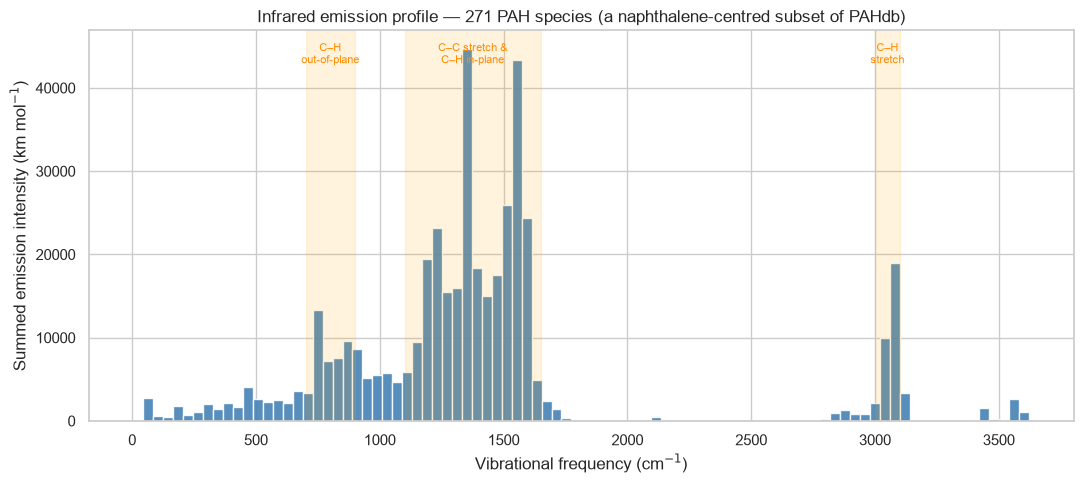

In [10]:
# Q1 VISUALIZATION: where the infrared EMISSION concentrates in frequency.
# Weight each line by its intensity, so the bars show emitted power per frequency bin
# (an "emission profile") rather than a raw count of modes. The characteristic PAH bands
# emerge from the data itself; the shaded regions simply name the peaks for the reader.
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(transitions["frequency"], bins=90, weights=transitions["intensity"],
        color="steelblue", edgecolor="white", alpha=0.9)
ymax = ax.get_ylim()[1]

# Shade and name the characteristic PAH emission bands (aligned with the emergent peaks).
bands = [
    (700, 900, "C–H\nout-of-plane"),
    (1100, 1650, "C–C stretch &\nC–H in-plane"),
    (3000, 3100, "C–H\nstretch"),
]
for lo, hi, label in bands:
    ax.axvspan(lo, hi, color="orange", alpha=0.13)
    ax.text((lo + hi) / 2, ymax * 0.97, label, ha="center", va="top",
            fontsize=8, color="darkorange")

ax.set_xlabel("Vibrational frequency (cm$^{-1}$)")
ax.set_ylabel("Summed emission intensity (km mol$^{-1}$)")
ax.set_title("Infrared emission profile — 271 PAH species (a naphthalene-centred subset of PAHdb)")
plt.tight_layout()
plt.show()


**Observations.** With the lines weighted by intensity, the concentration is now visible directly in the bars: about **two-thirds of all emitted infrared power falls between ~1100 and 1650 cm⁻¹** — the aromatic **C–C stretching** and **C–H in-plane bending** bands (the "6–9 µm" features) — with smaller contributions from the **C–H stretch near 3050 cm⁻¹** and the **C–H out-of-plane bends around 700–900 cm⁻¹**. The **~1700–3000 cm⁻¹ region is essentially empty**. Two side effects worth noting: the IR-silent modes simply disappear here (zero intensity adds nothing), and because this subset is **cation-rich**, emission is pulled toward the 6–9 µm region — cations are known to emit strongly there. That charge dependence is exactly what we test in the bivariate section.


### Q2 — What ionization states make up the molecule set?

**What do neutral / cation / anion mean?** A molecule is **neutral** when its positive and negative charges balance out. If it **loses** an electron it becomes positively charged — a **cation**; if it **gains** an electron it becomes negatively charged — an **anion**. (In space, PAHs are ionized by ultraviolet starlight, which is why all three forms occur.) Because adding or removing an electron changes how charge is spread across the molecule, it changes how strongly each vibration emits infrared light — the effect we investigate in the bivariate and multivariate sections.

Ionization is therefore the property we expect to reshape the spectrum, so before comparing spectra we look at how many **neutral**, **cation**, and **anion** species we have. We use the species-level view (`molecules_species`, 271 rows) so isomer duplicates in the full table don't inflate the counts.


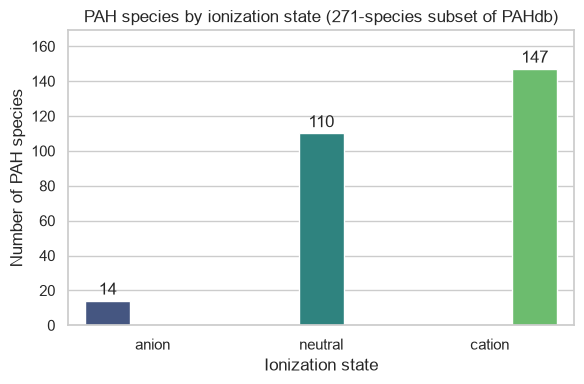

In [9]:
# Q2 VISUALIZATION: how many species of each ionization state (species level, n = 271).
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=molecules_species, x="charge_state", order=charge_order,
              hue="charge_state", palette="viridis", legend=False, ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=2)
ax.set_xlabel("Ionization state")
ax.set_ylabel("Number of PAH species")
ax.set_title("PAH species by ionization state (271-species subset of PAHdb)")
ax.margins(y=0.15)
plt.tight_layout()
plt.show()


**Observations.** The set is dominated by **cations (147)** and **neutrals (110)**, with only **14 anions** — a strong class imbalance. Any later comparison across ionization states must treat the anion group cautiously (small sample), so we will prefer distributions and ratios over raw counts when contrasting charge states.


### Discuss the distribution(s) of your variable(s) of interest. Were there any unusual points? Did you need to perform any transformations?

The **emission profile** (frequency weighted by intensity) is strongly concentrated: most emitted power sits in the ~1100–1650 cm⁻¹ bands, with smaller peaks near 3050 and 700–900 cm⁻¹ and a genuine empty gap at ~1700–3000 cm⁻¹. The frequency axis itself needs no transformation (it is naturally bounded in cm⁻¹); the one deliberate choice was to **weight by intensity** rather than count modes, so the plot answers "where does emission concentrate?" instead of "how many modes exist?". A side note: the **15% of IR-silent lines** (intensity = 0, symmetry-forbidden modes) contribute nothing to this weighted view — we keep them in the data and will highlight them in the per-molecule fact-sheet spectrum.

### Of the features you investigated, were there any unusual distributions? Did you perform any operations on the data to tidy, adjust, or change the form of the data? If so, why did you do this?

The **charge_state** distribution is notably imbalanced (147 / 110 / 14). We encoded it as an ordered categorical during preliminary wrangling so the count plot reads anion → neutral → cation, and used the **species-level** view (271 rows) so formula-based isomer duplicates don't inflate the counts. We also keep in mind that all of these figures describe a **naphthalene-centred subset** of PAHdb, not the full population.


## Bivariate Exploration

> In this section, investigate relationships between pairs of variables in your data. Make sure the variables that you cover here have been introduced in some fashion in the previous section (univariate exploration).

> **Rubric Tip**: This part (Bivariate Exploration) should include at least one scatter plot, one box plot, and at least one clustered bar chart or heat map.

### Talk about some of the relationships you observed in this part of the investigation. How did the feature(s) of interest vary with other features in the dataset?

> Your answer here!

### Did you observe any interesting relationships between the other features (not the main feature(s) of interest)?

> Your answer here!

## Multivariate Exploration

> Create plots of three or more variables to investigate your data even
further. Make sure that your investigations are justified, and follow from
your work in the previous sections.

> **Rubric Tip**: This part (Multivariate Exploration) should include at least one Facet Plot, and one Plot Matrix or Scatterplot with multiple encodings.

>**Rubric Tip**: Think carefully about how you encode variables. Choose appropriate color schemes, markers, or even how Facets are chosen. Also, do not overplot or incorrectly plot ordinal data.

### Talk about some of the relationships you observed in this part of the investigation. Were there features that strengthened each other in terms of looking at your feature(s) of interest?

> Your answer here!

### Were there any interesting or surprising interactions between features?

> Your answer here!

## Conclusions
>You can write a summary of the main findings and reflect on the steps taken during the data exploration.

> **Rubric Tip**: Create a list of summary findings to make it easy to review.

> Remove all Tips mentioned above, before you convert this notebook to PDF/HTML.


> At the end of your report, make sure that you export the notebook as an html file from the `File > Download as... > HTML or PDF` menu. Make sure you keep track of where the exported file goes, so you can put it in the same folder as this notebook for project submission. Also, make sure you remove all of the quote-formatted guide notes like this one before you finish your report!

